In [1]:
import pandas as pd
import os

# Confirm exact filenames
pit_file = '2022 Tax Statistics - Chapter 2 PIT.xlsx'
cit_file = '2022 Tax Statistics -Chapter 3- Company Income Tax.xlsx'

# Confirm we can read the PIT file
xl = pd.ExcelFile(f'../data/raw/{pit_file}')
print("Municipal breakdown sheets available:")
for sheet in xl.sheet_names:
    if 'A2.10' in sheet and 'Map' not in sheet:
        print(f"  {sheet}")

Municipal breakdown sheets available:
  A2.10.1
  A2.10.1 continued
  A2.10.2
  A2.10.3
  A2.10.4
  A2.10.4 continued
  A2.10.5
  A2.10.6
  A2.10.7
  A2.10.8
  A2.10.8 continued
  A2.10.9


In [2]:
# ============================================
# 03_wealth.ipynb
# SARS PIT — MUNICIPAL WEALTH EXTRACTION
# ============================================

import pandas as pd
import numpy as np
import os

# ============================================
# FILE PATHS
# ============================================
pit_file = '../data/raw/2022 Tax Statistics - Chapter 2 PIT.xlsx'
cit_file = '../data/raw/2022 Tax Statistics -Chapter 3- Company Income Tax.xlsx'

# Confirm files exist
print("Files found:")
for f in [pit_file, cit_file]:
    exists = os.path.exists(f)
    print(f"  {f.split('/')[-1]}: {'YES' if exists else 'NO'}")

# ============================================
# PROVINCE TO SHEET MAPPING
# ============================================
province_sheets = {
    'Eastern Cape':  'A2.10.1',
    'Free State':    'A2.10.2',
    'Gauteng':       'A2.10.3',
    'KwaZulu-Natal': 'A2.10.4',
    'Limpopo':       'A2.10.5',
    'North West':    'A2.10.6',
    'Mpumalanga':    'A2.10.7',
    'Northern Cape': 'A2.10.8',
    'Western Cape':  'A2.10.9',
}

# ============================================
# EXTRACTION FUNCTION
# ============================================
def extract_municipal_pit(sheet_name, province_name):
    """
    Extracts municipal PIT data from a single SARS sheet.
    
    Each sheet has:
    1. Data rows — municipality name, code and actual counts
    2. A Total row marking the end of real data
    3. A percentage section repeating municipalities with ratios
    
    Strategy: stop reading at the first Total row.
    This cleanly captures only real data regardless of
    whether values are int or float.
    
    Column positions (0-indexed):
        2  = municipality name
        3  = municipality code
        8  = number of taxpayers 2021
        9  = taxable income R million 2021
        11 = average taxable income in Rands 2021
    """
    df_raw = pd.read_excel(
        pit_file,
        sheet_name=sheet_name,
        header=None
    )
    
    rows = []
    for _, row in df_raw.iterrows():
        name = row.iloc[2] if len(row) > 2 else None
        code = row.iloc[3] if len(row) > 3 else None
        
        # Stop at Total row — everything after is percentages
        if isinstance(name, str) and name.strip() == 'Total':
            break
        
        # Only extract valid municipality rows
        if (isinstance(code, str) and
            len(code.strip()) >= 2 and
            len(code.strip()) <= 8 and
            code.strip().isupper() and
            isinstance(name, str) and
            'Municipality' in str(name)):
            
            num_taxpayers  = row.iloc[8]  if len(row) > 8  else None
            taxable_income = row.iloc[9]  if len(row) > 9  else None
            avg_income     = row.iloc[11] if len(row) > 11 else None
            
            rows.append({
                'province':           province_name,
                'municipality':       name.strip(),
                'muni_code':          code.strip(),
                'num_taxpayers':      num_taxpayers,
                'taxable_income_rm':  taxable_income,
                'avg_taxable_income': avg_income
            })
    
    return pd.DataFrame(rows)

# ============================================
# RUN EXTRACTION
# ============================================
all_municipal = []

for province, sheet in province_sheets.items():
    print(f"Extracting {province}...")
    df_sheet = extract_municipal_pit(sheet, province)
    all_municipal.append(df_sheet)
    print(f"  {sheet}: {len(df_sheet)} municipalities")

# Combine all provinces
municipal_pit = pd.concat(all_municipal, ignore_index=True)

# ============================================
# CLEAN UP
# ============================================
# Convert numeric columns to proper types
municipal_pit['num_taxpayers'] = pd.to_numeric(
    municipal_pit['num_taxpayers'], errors='coerce')
municipal_pit['taxable_income_rm'] = pd.to_numeric(
    municipal_pit['taxable_income_rm'], errors='coerce')
municipal_pit['avg_taxable_income'] = pd.to_numeric(
    municipal_pit['avg_taxable_income'], errors='coerce')

# Round avg income to whole Rands
municipal_pit['avg_taxable_income'] = (
    municipal_pit['avg_taxable_income'].round(0))

# ============================================
# VERIFICATION
# ============================================
print(f"\nTotal municipalities extracted: {len(municipal_pit)}")
print(f"\nNote: SA has 257 municipalities total.")
print(f"      {257 - len(municipal_pit)} municipalities have no")
print(f"      SARS assessed taxpayers and are excluded.")
print(f"\nBy province:")
print(municipal_pit.groupby('province').size().to_string())
print(f"\nDtypes:")
print(municipal_pit.dtypes)
print(f"\nNulls:")
print(municipal_pit.isnull().sum())
print(f"\nSample:")
print(municipal_pit.head(10).to_string())
print(f"\nAverage taxable income range:")
print(f"  Min:  R{municipal_pit['avg_taxable_income'].min():,.0f}")
print(f"  Max:  R{municipal_pit['avg_taxable_income'].max():,.0f}")
print(f"  Mean: R{municipal_pit['avg_taxable_income'].mean():,.0f}")
print(f"\nTop 5 wealthiest municipalities:")
print(municipal_pit.nlargest(5, 'avg_taxable_income')[
    ['province', 'municipality', 'avg_taxable_income', 'num_taxpayers']
].to_string())
print(f"\nBottom 5 least wealthy municipalities:")
print(municipal_pit.nsmallest(5, 'avg_taxable_income')[
    ['province', 'municipality', 'avg_taxable_income', 'num_taxpayers']
].to_string())

# ============================================
# SAVE CLEANED FILE
# ============================================
municipal_pit.to_csv(
    '../data/cleaned/SARS_municipal_PIT_2021_cleaned.csv',
    index=False
)
print(f"\nSaved to data/cleaned/SARS_municipal_PIT_2021_cleaned.csv")

Files found:
  2022 Tax Statistics - Chapter 2 PIT.xlsx: YES
  2022 Tax Statistics -Chapter 3- Company Income Tax.xlsx: YES
Extracting Eastern Cape...
  A2.10.1: 33 municipalities
Extracting Free State...
  A2.10.2: 19 municipalities
Extracting Gauteng...
  A2.10.3: 9 municipalities
Extracting KwaZulu-Natal...
  A2.10.4: 44 municipalities
Extracting Limpopo...
  A2.10.5: 22 municipalities
Extracting North West...
  A2.10.6: 18 municipalities
Extracting Mpumalanga...
  A2.10.7: 17 municipalities
Extracting Northern Cape...
  A2.10.8: 26 municipalities
Extracting Western Cape...
  A2.10.9: 25 municipalities

Total municipalities extracted: 213

Note: SA has 257 municipalities total.
      44 municipalities have no
      SARS assessed taxpayers and are excluded.

By province:
province
Eastern Cape     33
Free State       19
Gauteng           9
KwaZulu-Natal    44
Limpopo          22
Mpumalanga       17
North West       18
Northern Cape    26
Western Cape     25

Dtypes:
province          

## SARS Municipal PIT Data — Key Findings

**Data coverage:**
213 of 257 municipalities have assessed taxpayers.
44 municipalities invisible to SARS — entirely outside
formal economy. Likely highest correlation with low DES scores.

**Wealth range:**
Min average taxable income: R170,257 (Thembelihle, NC)
Max average taxable income: R469,674 (Gamagara, NC)
National municipal mean: R261,748

**Key insight — Northern Cape paradox:**
3 of 5 wealthiest municipalities by average income
are in Northern Cape — a province ranked 4th on DES.
Mining wealth concentrated in small enclaves does not
translate to provincial service delivery quality.
This is the wealth vs development gap in its purest form.

**Data note:**
SARS data covers tax year 2021.
GHS data covers survey year 2022.
One year lag is acceptable for correlation analysis.

In [3]:
# ============================================
# DOWNLOAD MUNICIPAL MONEY BULK DATA
# ============================================

import urllib.request
import os

# Files to download — all aligned to 2021 to match SARS data
downloads = {
    'capital_facts_v2_2021.csv': 
        'https://munimoney-media.s3.eu-west-1.amazonaws.com/munimoney-media/media/bulk_downloads/capital_facts_v2/capital_facts_v2_2021__2024-08-15_22-29-03.csv',
    
    'audit_opinion_facts.csv':
        'https://munimoney-media.s3.eu-west-1.amazonaws.com/munimoney-media/media/bulk_downloads/audit_opinion_facts/audit_opinion_facts_2024-02-19_15-46-13.csv',
    
    'uifw_expenditure_facts.csv':
        'https://munimoney-media.s3.eu-west-1.amazonaws.com/munimoney-media/media/bulk_downloads/uifwexp_facts/uifwexp_facts_2024-02-19_15-46-13.csv',
}

raw_path = '../data/raw/'

for filename, url in downloads.items():
    filepath = os.path.join(raw_path, filename)
    if os.path.exists(filepath):
        print(f"Already exists: {filename}")
    else:
        print(f"Downloading {filename}...")
        try:
            urllib.request.urlretrieve(url, filepath)
            size = os.path.getsize(filepath) / 1024 / 1024
            print(f"  Saved: {size:.1f} MB")
        except Exception as e:
            print(f"  Failed: {e}")

print("\nDownload complete.")

Already exists: capital_facts_v2_2021.csv
Already exists: audit_opinion_facts.csv


  Failed: HTTP Error 403: Forbidden

Download complete.


In [4]:
# ============================================
# DOWNLOAD REMAINING MUNICIPAL MONEY FILES
# ============================================

import urllib.request
import os

raw_path = '../data/raw/'

# UIFW — download via the explore table API
# The API allows direct CSV export with parameters
uifw_url = ('https://municipaldata.treasury.gov.za/api/cubes/uifwexp/facts'
            '?format=csv'
            '&cut=financial_year_end.year:2021'
            '&fields=demarcation.code,demarcation.label,'
            'financial_year_end.year,item.code,item.label,amount')

print("Downloading UIFW expenditure via API...")
try:
    urllib.request.urlretrieve(
        uifw_url,
        os.path.join(raw_path, 'uifw_expenditure_2021.csv')
    )
    size = os.path.getsize(
        os.path.join(raw_path, 'uifw_expenditure_2021.csv')
    ) / 1024
    print(f"  Saved: {size:.1f} KB")
except Exception as e:
    print(f"  Failed: {e}")

# Also get audit opinions via API for 2021
audit_url = ('https://municipaldata.treasury.gov.za/api/cubes/audit_opinions/facts'
             '?format=csv'
             '&cut=financial_year_end.year:2021'
             '&fields=demarcation.code,demarcation.label,'
             'financial_year_end.year,opinion.code,opinion.label')

print("Downloading audit opinions 2021 via API...")
try:
    urllib.request.urlretrieve(
        audit_url,
        os.path.join(raw_path, 'audit_opinions_2021.csv')
    )
    size = os.path.getsize(
        os.path.join(raw_path, 'audit_opinions_2021.csv')
    ) / 1024
    print(f"  Saved: {size:.1f} KB")
except Exception as e:
    print(f"  Failed: {e}")

print("\nDone.")

  Saved: 52.0 KB
  Saved: 17.0 KB

Done.


In [5]:
# ============================================
# VERIFY ALL DOWNLOADED FILES
# ============================================

import pandas as pd
import os

raw_path = '../data/raw/'

files_to_check = {
    'capital_facts_v2_2021.csv': 'Capital expenditure',
    'audit_opinion_facts.csv': 'Audit opinions (all years)',
    'audit_opinions_2021.csv': 'Audit opinions (2021 only)',
    'uifw_expenditure_2021.csv': 'UIFW expenditure (2021)',
}

for filename, description in files_to_check.items():
    filepath = os.path.join(raw_path, filename)
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        print(f"\n{description}")
        print(f"  File: {filename}")
        print(f"  Shape: {df.shape}")
        print(f"  Columns: {df.columns.tolist()}")
        print(f"  Sample row: {df.iloc[0].to_dict()}")
    else:
        print(f"\nMISSING: {filename}")


Capital expenditure
  File: capital_facts_v2_2021.csv
  Shape: (338572, 10)
  Columns: ['demarcation_code', 'period_code', 'financial_year', 'period_length', 'financial_period', 'amount_type', 'function', 'item', 'capital_type', 'amount']
  Sample row: {'demarcation_code': 'BUF', 'period_code': '2021IBY1', 'financial_year': 2021, 'period_length': 'year', 'financial_period': 2021, 'amount_type': 'IBY1', 'function': 1110, 'item': 210, 'capital_type': 'DEPRECIATION', 'amount': 116237.0}

Audit opinions (all years)
  File: audit_opinion_facts.csv
  Shape: (3174, 5)
  Columns: ['demarcation_code', 'financial_year', 'opinion_code', 'opinion_label', 'report_url']
  Sample row: {'demarcation_code': 'EC123', 'financial_year': 2015, 'opinion_code': 'qualified', 'opinion_label': 'Qualified', 'report_url': nan}

Audit opinions (2021 only)
  File: audit_opinions_2021.csv
  Shape: (257, 5)
  Columns: ['demarcation.code', 'demarcation.label', 'financial_year_end.year', 'opinion.code', 'opinion.label

In [6]:
# ============================================
# REPROCESS CAPITAL EXPENDITURE
# ACT rows are monthly — aggregate to annual
# ============================================

import pandas as pd
import numpy as np

raw_path = '../data/raw/'
cleaned_path = '../data/cleaned/'

print("Processing capital expenditure...")
capex_raw = pd.read_csv(f'{raw_path}capital_facts_v2_2021.csv')

# ACT rows are monthly — filter to ACT and sum across
# all months per municipality to get annual total
capex_act = capex_raw[
    capex_raw['amount_type'] == 'ACT'
].copy()

print(f"  ACT rows (monthly): {len(capex_act)}")
print(f"  Financial years present: "
      f"{capex_act['financial_year'].unique()}")
print(f"  Months per municipality sample:")
print(capex_act.groupby('demarcation_code')[
    'financial_period'].nunique().describe())

# Aggregate to annual total per municipality
# Sum all months and all spending categories
capex_annual = capex_act.groupby(
    'demarcation_code'
)['amount'].sum().reset_index()

capex_annual.columns = ['muni_code', 'total_capex']

# Convert to R millions
capex_annual['total_capex_rm'] = (
    capex_annual['total_capex'] / 1_000_000
).round(2)

# Remove zeros and negatives
# Zero capex means no data submitted not zero spending
capex_annual = capex_annual[
    capex_annual['total_capex'] > 0
]

print(f"\n  Municipalities with capex data: {len(capex_annual)}")
print(f"\n  Capex range:")
print(f"  Min:  R{capex_annual['total_capex_rm'].min():.2f}M")
print(f"  Max:  R{capex_annual['total_capex_rm'].max():.2f}M")
print(f"  Mean: R{capex_annual['total_capex_rm'].mean():.2f}M")

print(f"\n  Top 10 spenders:")
print(capex_annual.nlargest(10, 'total_capex_rm')[
    ['muni_code', 'total_capex_rm']
].to_string())

print(f"\n  Bottom 10 spenders:")
print(capex_annual.nsmallest(10, 'total_capex_rm')[
    ['muni_code', 'total_capex_rm']
].to_string())

# Also get budget vs actual comparison
# ADJB is adjusted budget — compare to ACT for underspending
capex_budget = capex_raw[
    (capex_raw['amount_type'] == 'ADJB') &
    (capex_raw['period_length'] == 'year')
].groupby('demarcation_code')['amount'].sum().reset_index()
capex_budget.columns = ['muni_code', 'total_budget']
capex_budget['total_budget_rm'] = (
    capex_budget['total_budget'] / 1_000_000
).round(2)

# Merge actual and budget
capex_compare = capex_annual.merge(
    capex_budget, on='muni_code', how='left')

# Calculate spending ratio
# 1.0 = spent exactly budget
# < 1.0 = underspent
# > 1.0 = overspent
capex_compare['spending_ratio'] = (
    capex_compare['total_capex'] /
    capex_compare['total_budget']
).round(3)

# Underspending percentage
capex_compare['underspend_pct'] = (
    (1 - capex_compare['spending_ratio']) * 100
).round(1)

print(f"\n  Worst underspenders (budget vs actual):")
worst_spend = capex_compare[
    capex_compare['spending_ratio'].notna()
].nsmallest(10, 'spending_ratio')[
    ['muni_code', 'total_budget_rm',
     'total_capex_rm', 'spending_ratio']
]
print(worst_spend.to_string(index=False))

# Save
capex_compare.to_csv(
    f'{cleaned_path}municipal_capex_2021_cleaned.csv',
    index=False
)
print(f"\n  Saved: municipal_capex_2021_cleaned.csv")

Processing capital expenditure...
  ACT rows (monthly): 167541
  Financial years present: [2021]
  Months per municipality sample:
count    256.000000
mean      11.402344
std        1.608261
min        2.000000
25%       12.000000
50%       12.000000
75%       12.000000
max       12.000000
Name: financial_period, dtype: float64

  Municipalities with capex data: 247

  Capex range:
  Min:  R0.16M
  Max:  R10841.05M
  Mean: R413.77M

  Top 10 spenders:
    muni_code  total_capex_rm
103       JHB        10841.05
77        EKU         9158.92
1         CPT         8945.06
78        ETH         8388.70
231       TSH         6449.88
112    KZN225         4377.00
0         BUF         3003.87
14       DC22         2783.28
167    LIM473         2299.30
169       MAN         2247.78

  Bottom 10 spenders:
    muni_code  total_capex_rm
8        DC16            0.16
82      FS181            0.77
30       DC37            1.66
41        DC5            1.66
44        DC8            1.74
198     NC0

## Municipal Money Findings — Capital Expenditure 2021

**Coverage:** 247 of 257 municipalities submitted capex data.

**Scale range:**
- Highest: City of Johannesburg R10.8 billion
- Lowest: DC16 (Xhariep District) R160,000
- National mean: R413.77 million

**Critical underspenders — spending ratio < 15%:**
- Masilonyana (FS): budgeted R62M, spent R770K — 1.2%
- Renosterberg (NC): budgeted R34M, spent R1.8M — 5.2%
- Mamusa (NW): budgeted R74M, spent R5.1M — 6.8%
- Kopanong (FS): budgeted R126M, spent R10M — 8.0%

**Key finding:**
Worst capex underspenders overlap significantly with
municipalities that have disclaimer or outstanding audits.
Cannot spend budget + cannot produce clean audit =
service delivery failure. This will correlate with
low provincial DES scores for Free State rural areas
and North West.

**Audit findings 2021:**
- Clean audits (score 4-5): 40 municipalities (15.6%)
- Qualified: 71 municipalities (27.6%)
- Disclaimer/Adverse: 22 municipalities (8.6%)
- Outstanding (not submitted): 24 municipalities (9.3%)
- 46 municipalities in governance crisis

In [7]:
# ============================================
# MUNICIPALITY REFERENCE TABLE
# Pull from Municipal Money municipalities API
# ============================================

import pandas as pd
import urllib.request
import os

raw_path = '../data/raw/'
cleaned_path = '../data/cleaned/'

# Download municipality reference data from API
muni_url = ('https://municipaldata.treasury.gov.za/api/'
            'cubes/municipalities/facts'
            '?format=csv'
            '&fields=municipality.demarcation_code,'
            'municipality.name,'
            'municipality.long_name,'
            'municipality.province_name,'
            'municipality.category,'
            'municipality.miif_category')

ref_path = os.path.join(raw_path, 'municipality_reference.csv')

if not os.path.exists(ref_path):
    print("Downloading municipality reference data...")
    urllib.request.urlretrieve(muni_url, ref_path)
    print("  Downloaded.")
else:
    print("Reference file already exists.")

# Load and clean
muni_ref = pd.read_csv(ref_path)
muni_ref.columns = [
    c.replace('municipality.', '')
    for c in muni_ref.columns
]

# Rename for clarity
muni_ref = muni_ref.rename(columns={
    'demarcation_code': 'muni_code',
    'name':             'muni_name',
    'long_name':        'muni_long_name',
    'province_name':    'province',
    'category':         'muni_category',
    'miif_category':    'miif_category'
})

print(f"\nReference table shape: {muni_ref.shape}")
print(f"\nCategories:")
print(muni_ref['muni_category'].value_counts().to_string())
print(f"\nSample:")
print(muni_ref.head(10)[[
    'muni_code', 'muni_name', 'province', 'muni_category'
]].to_string())

# Save
muni_ref.to_csv(
    f'{cleaned_path}municipality_reference_cleaned.csv',
    index=False
)
print(f"\nSaved: municipality_reference_cleaned.csv")

Reference file already exists.

Reference table shape: (292, 6)

Categories:
muni_category
B    240
C     44
A      8

Sample:
  muni_code       muni_name      province muni_category
0       BUF    Buffalo City  Eastern Cape             A
1       CPT       Cape Town  Western Cape             A
2       DC1      West Coast  Western Cape             C
3      DC10  Sarah Baartman  Eastern Cape             C
4      DC12        Amathole  Eastern Cape             C
5      DC13      Chris Hani  Eastern Cape             C
6      DC14       Joe Gqabi  Eastern Cape             C
7      DC15       O R Tambo  Eastern Cape             C
8      DC16         Xhariep    Free State             C
9      DC18   Lejweleputswa    Free State             C

Saved: municipality_reference_cleaned.csv


In [8]:
# ============================================
# FIX ISSUES AND REBUILD MASTER DATASET
# ============================================

import pandas as pd
import numpy as np

cleaned_path = '../data/cleaned/'

# Reload all datasets
municipal_pit = pd.read_csv(
    f'{cleaned_path}SARS_municipal_PIT_2021_cleaned.csv')
capex = pd.read_csv(
    f'{cleaned_path}municipal_capex_2021_cleaned.csv')
audit = pd.read_csv(
    f'{cleaned_path}municipal_audit_2021_cleaned.csv')
uifw = pd.read_csv(
    f'{cleaned_path}municipal_uifw_2021_cleaned.csv')
muni_ref = pd.read_csv(
    f'{cleaned_path}municipality_reference_cleaned.csv')

# ============================================
# FIX 1 — Standardise province names
# ============================================
province_fix = {
    'Kwazulu-Natal': 'KwaZulu-Natal',
    'kwazulu-natal': 'KwaZulu-Natal',
    'KWAZULU-NATAL': 'KwaZulu-Natal',
}

muni_ref['province'] = muni_ref['province'].replace(province_fix)

print("Province names after fix:")
print(muni_ref['province'].value_counts().to_string())

# ============================================
# FIX 2 — Correct governance score mapping
# Check actual opinion codes in audit data
# ============================================
print(f"\nActual opinion codes in audit data:")
print(audit['opinion_code'].value_counts().to_string())

# Fix the score mapping with correct codes
opinion_scores = {
    'unqualified':                    5,
    'unqualified_emphasis_of_matter': 4,
    'qualified':                      3,
    'adverse':                        2,
    'disclaimer':                     1,
    'outstanding':                    0,
}

audit['governance_score'] = audit[
    'opinion_code'].map(opinion_scores)

print(f"\nGovernance scores after fix:")
print(audit['governance_score'].value_counts()
      .sort_index(ascending=False).to_string())
print(f"Nulls remaining: {audit['governance_score'].isna().sum()}")

# Save fixed audit file
audit.to_csv(
    f'{cleaned_path}municipal_audit_2021_cleaned.csv',
    index=False
)

# ============================================
# REBUILD MASTER DATASET
# ============================================
muni_base = muni_ref[
    muni_ref['muni_category'].isin(['A', 'B'])
].copy()

master = muni_base.merge(
    municipal_pit[[
        'muni_code', 'num_taxpayers',
        'taxable_income_rm', 'avg_taxable_income'
    ]],
    on='muni_code', how='left'
)

master = master.merge(
    capex[[
        'muni_code', 'total_capex_rm',
        'total_budget_rm', 'spending_ratio',
        'underspend_pct'
    ]],
    on='muni_code', how='left'
)

master = master.merge(
    audit[[
        'muni_code', 'opinion_code',
        'opinion_label', 'governance_score'
    ]],
    on='muni_code', how='left'
)

master = master.merge(
    uifw[['muni_code', 'uifw_total_rm']],
    on='muni_code', how='left'
)

# ============================================
# VERIFICATION
# ============================================
print(f"\nMaster shape: {master.shape}")
print(f"\nData coverage:")
for col in master.columns:
    filled = master[col].notna().sum()
    pct = filled / len(master) * 100
    print(f"  {col:<25} {filled:>3}/{len(master)} ({pct:.0f}%)")

print(f"\nProvinces (should be 9 unique):")
print(master['province'].value_counts().to_string())

print(f"\nAverage income by province:")
print(master.groupby('province')[
    'avg_taxable_income'
].mean().sort_values(ascending=False)
  .apply(lambda x: f"R{x:,.0f}").to_string())

print(f"\nAverage governance score by province:")
print(master.groupby('province')[
    'governance_score'
].mean().sort_values(ascending=False)
  .round(2).to_string())

print(f"\nAverage capex spending ratio by province:")
print(master.groupby('province')[
    'spending_ratio'
].mean().sort_values(ascending=False)
  .round(3).to_string())

# Save
master.to_csv(
    f'{cleaned_path}master_municipal_2021.csv',
    index=False
)
print(f"\nSaved: master_municipal_2021.csv")

Province names after fix:
province
KwaZulu-Natal    65
Eastern Cape     48
Limpopo          33
Northern Cape    33
Western Cape     30
Free State       24
North West       24
Mpumalanga       22
Gauteng          13

Actual opinion codes in audit data:
opinion_code
unqualified_emphasis_of_matter    100
qualified                          71
unqualified                        40
outstanding                        24
disclaimer                         18
adverse                             4

Governance scores after fix:
governance_score
5     40
4    100
3     71
2      4
1     18
0     24
Nulls remaining: 0

Master shape: (248, 17)

Data coverage:
  muni_code                 248/248 (100%)
  muni_name                 248/248 (100%)
  muni_long_name            248/248 (100%)
  province                  248/248 (100%)
  muni_category             248/248 (100%)
  miif_category             248/248 (100%)
  num_taxpayers             213/248 (86%)
  taxable_income_rm         213/248 (86%)
  av

## Master Municipal Dataset — Key Findings

**Coverage:** 248 A and B municipalities
Data completeness: 86% across all financial variables
35 municipalities missing from SARS data — outside
formal economy entirely.

**Income paradox:**
Limpopo ranks 2nd on average taxable income (R293,447)
despite ranking last on GHS service delivery.
SARS only captures formal economy taxpayers —
Limpopo's average is inflated by mining/agricultural
specialists while majority of households are informal.

**Governance crisis provinces:**
- Free State: score 1.74, spending ratio 0.47
  Cannot govern AND cannot spend budget
- North West: score 2.00, spending ratio 0.42
  Lowest spending ratio nationally — structural collapse

**Eastern Cape overspending anomaly:**
Spending ratio 1.62 — spending 62% above budget
Possible explanations: conditional grants inflating
actuals, weak budget controls, unrealistic budgeting
Requires investigation in context of disclaimer audits

**Western Cape governance premium confirmed:**
Score 4.20 — highest nationally
Consistent across GHS service delivery, audit outcomes
and capex management

Municipalities with complete data: 205

By province:
province
KwaZulu-Natal    38
Eastern Cape     31
Northern Cape    26
Western Cape     25
Limpopo          22
Free State       19
North West       18
Mpumalanga       17
Gauteng           9

Correlation matrix:
                    avg_taxable_income  total_capex_rm  spending_ratio  governance_score  uifw_total_rm
avg_taxable_income               1.000           0.388          -0.018             0.201          0.427
total_capex_rm                   0.388           1.000           0.115             0.160          0.559
spending_ratio                  -0.018           0.115           1.000            -0.028         -0.018
governance_score                 0.201           0.160          -0.028             1.000          0.031
uifw_total_rm                    0.427           0.559          -0.018             0.031          1.000

Key correlations:
  Wealth vs governance quality: r = 0.201
  Wealth vs capex spending ratio: r = -0.018
  Wealt

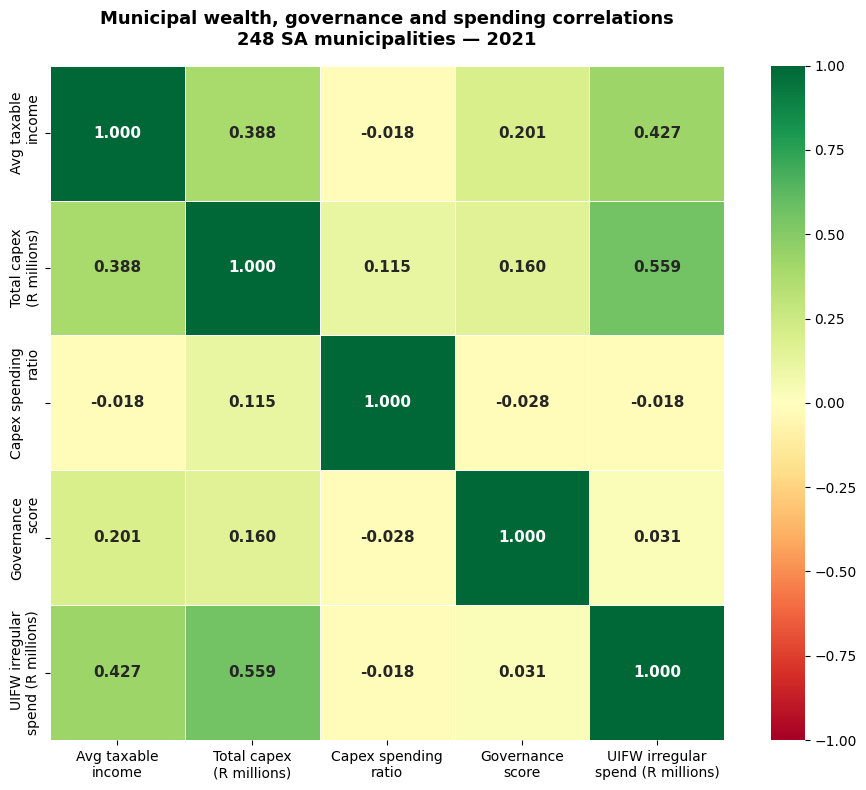

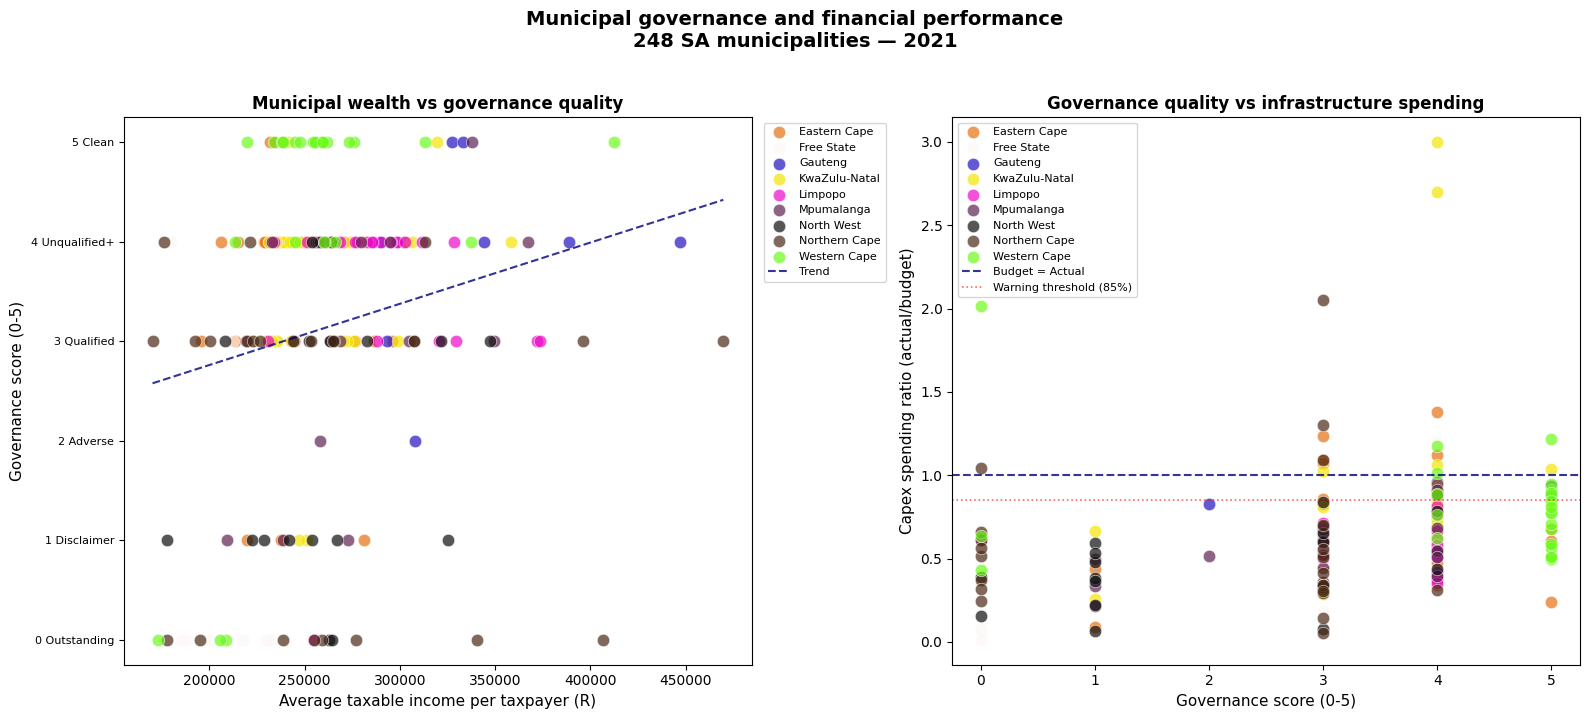

In [9]:
# ============================================
# WEALTH VS GOVERNANCE CORRELATION ANALYSIS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

master = pd.read_csv(
    '../data/cleaned/master_municipal_2021.csv')

# ============================================
# STEP 1 — Select analysis variables
# Only use rows with complete data
# ============================================
analysis_cols = [
    'avg_taxable_income',
    'total_capex_rm',
    'spending_ratio',
    'governance_score',
    'uifw_total_rm'
]

analysis_df = master[
    ['muni_code', 'muni_name', 'province',
     'muni_category'] + analysis_cols
].dropna(subset=analysis_cols).copy()

print(f"Municipalities with complete data: {len(analysis_df)}")
print(f"\nBy province:")
print(analysis_df.groupby('province').size()
      .sort_values(ascending=False).to_string())

# ============================================
# STEP 2 — Correlation matrix
# ============================================
print(f"\nCorrelation matrix:")
corr_matrix = analysis_df[analysis_cols].corr().round(3)
print(corr_matrix.to_string())

# ============================================
# STEP 3 — Key correlations with narrative
# ============================================
print(f"\nKey correlations:")

pairs = [
    ('avg_taxable_income', 'governance_score',
     'Wealth vs governance quality'),
    ('avg_taxable_income', 'spending_ratio',
     'Wealth vs capex spending ratio'),
    ('avg_taxable_income', 'uifw_total_rm',
     'Wealth vs irregular expenditure'),
    ('governance_score', 'spending_ratio',
     'Governance quality vs spending ratio'),
    ('governance_score', 'uifw_total_rm',
     'Governance quality vs irregular expenditure'),
    ('total_capex_rm', 'avg_taxable_income',
     'Total capex vs average income'),
]

for col1, col2, label in pairs:
    r = analysis_df[[col1, col2]].corr().iloc[0, 1]
    print(f"  {label}: r = {r:.3f}")

# ============================================
# STEP 4 — Build correlation heatmap
# ============================================
fig, ax = plt.subplots(figsize=(10, 8))

display_names = {
    'avg_taxable_income': 'Avg taxable\nincome',
    'total_capex_rm':     'Total capex\n(R millions)',
    'spending_ratio':     'Capex spending\nratio',
    'governance_score':   'Governance\nscore',
    'uifw_total_rm':      'UIFW irregular\nspend (R millions)'
}

corr_display = corr_matrix.rename(
    index=display_names, columns=display_names)

mask = np.triu(np.ones_like(corr_display, dtype=bool), k=1)

sns.heatmap(
    corr_display,
    ax=ax,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'},
    square=True
)

ax.set_title(
    'Municipal wealth, governance and spending correlations\n'
    '248 SA municipalities — 2021',
    fontsize=13,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.savefig(
    '../outputs/municipal_correlation_heatmap.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# ============================================
# STEP 5 — Scatter plot wealth vs governance
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left — income vs governance score
province_colors = {
    'Western Cape':    "#6cfa1a",
    'Gauteng':         "#2312c0",
    'KwaZulu-Natal':   "#f5e503",
    'Eastern Cape':    "#e47112",
    'Limpopo':         "#ec08c6",
    'Free State':      "#fcf7f6",
    'North West':      "#0f0f0f",
    'Mpumalanga':      "#5f2350",
    'Northern Cape':   "#4b2a17",
}

for province, group in analysis_df.groupby('province'):
    color = province_colors.get(province, '#999999')
    axes[0].scatter(
        group['avg_taxable_income'],
        group['governance_score'],
        c=color,
        label=province,
        alpha=0.7,
        s=80,
        edgecolors='white',
        linewidth=0.5
    )

# Add trend line
z = np.polyfit(
    analysis_df['avg_taxable_income'].fillna(0),
    analysis_df['governance_score'].fillna(0),
    1
)
p = np.poly1d(z)
x_line = np.linspace(
    analysis_df['avg_taxable_income'].min(),
    analysis_df['avg_taxable_income'].max(),
    100
)
axes[0].plot(
    x_line, p(x_line),
    'navy', linestyle='--',
    linewidth=1.5, alpha=0.8,
    label='Trend'
)

axes[0].set_xlabel(
    'Average taxable income per taxpayer (R)', fontsize=11)
axes[0].set_ylabel('Governance score (0-5)', fontsize=11)
axes[0].set_title(
    'Municipal wealth vs governance quality',
    fontweight='bold'
)
axes[0].legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    fontsize=8
)
axes[0].set_yticks([0, 1, 2, 3, 4, 5])
axes[0].set_yticklabels([
    '0 Outstanding',
    '1 Disclaimer',
    '2 Adverse',
    '3 Qualified',
    '4 Unqualified+',
    '5 Clean'
], fontsize=8)

# Right — governance score vs spending ratio
# Remove extreme outliers for readability
spend_clean = analysis_df[
    analysis_df['spending_ratio'] <= 3
].copy()

for province, group in spend_clean.groupby('province'):
    color = province_colors.get(province, '#999999')
    axes[1].scatter(
        group['governance_score'],
        group['spending_ratio'],
        c=color,
        label=province,
        alpha=0.7,
        s=80,
        edgecolors='white',
        linewidth=0.5
    )

axes[1].axhline(
    y=1.0, color='navy',
    linestyle='--', linewidth=1.5,
    alpha=0.8, label='Budget = Actual'
)
axes[1].axhline(
    y=0.85, color='red',
    linestyle=':', linewidth=1.2,
    alpha=0.6, label='Warning threshold (85%)'
)

axes[1].set_xlabel('Governance score (0-5)', fontsize=11)
axes[1].set_ylabel(
    'Capex spending ratio (actual/budget)', fontsize=11)
axes[1].set_title(
    'Governance quality vs infrastructure spending',
    fontweight='bold'
)
axes[1].set_xticks([0, 1, 2, 3, 4, 5])
axes[1].legend(fontsize=8)

fig.suptitle(
    'Municipal governance and financial performance\n'
    '248 SA municipalities — 2021',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '../outputs/wealth_governance_scatter.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

In [10]:
# Add UIFW as percentage of capex budget
# This removes the size bias from the raw rand amount
master['uifw_pct_budget'] = (
    master['uifw_total_rm'] /
    master['total_budget_rm'] * 100
).round(2)

In [11]:
print(master[['muni_code', 'muni_name', 
              'uifw_total_rm', 'total_budget_rm', 
              'uifw_pct_budget']].dropna().head(10).to_string())
print(f"\nuifw_pct_budget nulls: {master['uifw_pct_budget'].isna().sum()}")
print(f"uifw_pct_budget range: {master['uifw_pct_budget'].min():.2f}% to {master['uifw_pct_budget'].max():.2f}%")

   muni_code             muni_name  uifw_total_rm  total_budget_rm  uifw_pct_budget
0        BUF          Buffalo City         311.22          3512.70             8.86
1        CPT             Cape Town         774.51         14392.87             5.38
2      EC101       Dr Beyers Naude          90.60           148.88            60.85
3      EC102      Blue Crane Route           8.23           106.63             7.72
5      EC104                Makana         129.21           115.16           112.20
6      EC105               Ndlambe         277.07           263.48           105.16
7      EC106  Sundays River Valley          76.56            49.02           156.18
9      EC108                 Kouga           3.58           239.38             1.50
10     EC109             Kou-Kamma          11.88            48.97            24.26
11     EC121               Mbhashe          21.32           173.94            12.26

uifw_pct_budget nulls: 43
uifw_pct_budget range: 0.00% to 816.62%


In [12]:
master.to_csv(
    '../data/cleaned/master_municipal_2021.csv',
    index=False
)
print("Master dataset saved.")
print(f"Shape: {master.shape}")
print(f"Columns: {master.columns.tolist()}")

Master dataset saved.
Shape: (248, 18)
Columns: ['muni_code', 'muni_name', 'muni_long_name', 'province', 'muni_category', 'miif_category', 'num_taxpayers', 'taxable_income_rm', 'avg_taxable_income', 'total_capex_rm', 'total_budget_rm', 'spending_ratio', 'underspend_pct', 'opinion_code', 'opinion_label', 'governance_score', 'uifw_total_rm', 'uifw_pct_budget']


Municipalities for clustering: 205

Feature summary:
       avg_taxable_income  governance_score  spending_ratio  uifw_pct_budget
count              205.00            205.00          205.00           205.00
mean            262607.53              3.15            0.95            73.27
std              48250.04              1.48            2.41           107.44
min             170257.00              0.00            0.01             0.00
25%             234090.00              3.00            0.44             8.03
50%             254479.00              4.00            0.62            34.60
75%             282770.00              4.00            0.83           100.22
max             469674.00              5.00           29.00           816.62

After capping UIFW at 200%:
  Max UIFW pct: 200.0%

After scaling:
  Mean of each feature (should be ~0):
    avg_taxable_income: -0.0000
    governance_score: -0.0000
    spending_ratio: -0.0000
    uifw_pct_budget: 0.0000
  Std of each feature (should

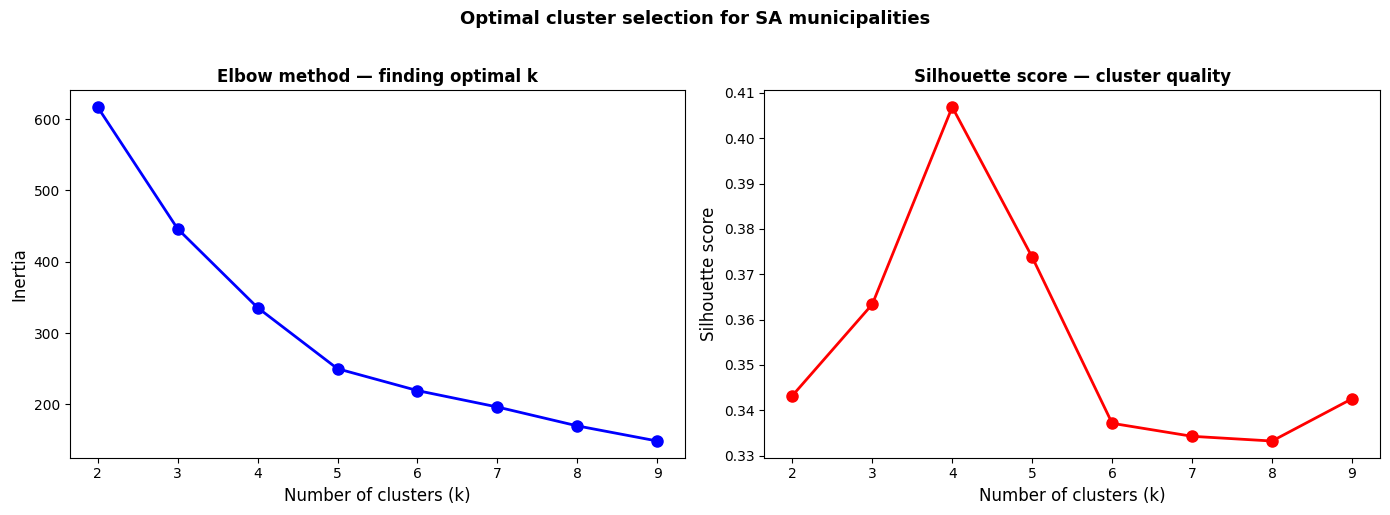


Best silhouette score: k=4 (0.407)
Recommendation: use k with highest silhouette score


In [13]:
# ============================================
# K-MEANS CLUSTERING
# Municipal governance and wealth profiles
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

master = pd.read_csv(
    '../data/cleaned/master_municipal_2021.csv')

# ============================================
# STEP 1 — Prepare features
# ============================================
features = [
    'avg_taxable_income',
    'governance_score',
    'spending_ratio',
    'uifw_pct_budget'
]

# Keep only rows with complete feature data
cluster_df = master[
    ['muni_code', 'muni_name', 'province',
     'muni_category'] + features
].dropna().copy()

print(f"Municipalities for clustering: {len(cluster_df)}")
print(f"\nFeature summary:")
print(cluster_df[features].describe().round(2).to_string())

# ============================================
# STEP 2 — Cap extreme outliers before scaling
# UIFW pct above 200% is an extreme outlier
# that will distort the clustering
# ============================================
cluster_df['uifw_pct_budget'] = cluster_df[
    'uifw_pct_budget'].clip(upper=200)

print(f"\nAfter capping UIFW at 200%:")
print(f"  Max UIFW pct: {cluster_df['uifw_pct_budget'].max():.1f}%")

# ============================================
# STEP 3 — Scale features using StandardScaler
# This is the critical step NotebookLM flagged
# Without this income in hundreds of thousands
# would dominate over governance score of 0-5
# ============================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[features])

print(f"\nAfter scaling:")
print(f"  Mean of each feature (should be ~0):")
for i, f in enumerate(features):
    print(f"    {f}: {X_scaled[:, i].mean():.4f}")
print(f"  Std of each feature (should be ~1):")
for i, f in enumerate(features):
    print(f"    {f}: {X_scaled[:, i].std():.4f}")

# ============================================
# STEP 4 — Find optimal k using elbow method
# ============================================
inertia_values = []
silhouette_values = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_values.append(sil_score)
    print(f"  k={k}: inertia={kmeans.inertia_:.1f} | "
          f"silhouette={sil_score:.3f}")

# ============================================
# STEP 5 — Plot elbow and silhouette
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia_values,
             'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title(
    'Elbow method — finding optimal k',
    fontweight='bold'
)
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouette_values,
             'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette score', fontsize=12)
axes[1].set_title(
    'Silhouette score — cluster quality',
    fontweight='bold'
)
axes[1].set_xticks(list(k_range))

fig.suptitle(
    'Optimal cluster selection for SA municipalities',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '../outputs/kmeans_elbow_silhouette.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print(f"\nBest silhouette score: "
      f"k={list(k_range)[silhouette_values.index(max(silhouette_values))]} "
      f"({max(silhouette_values):.3f})")
print(f"Recommendation: use k with highest silhouette score")

Cluster sizes:
cluster
0     50
1    125
2     28
3      2

Cluster profiles (mean values):
         avg_taxable_income  governance_score  spending_ratio  uifw_pct_budget
cluster                                                                       
0                 257033.24              2.70            0.60           159.40
1                 270212.12              3.97            0.83            26.23
2                 239662.64              0.36            0.51            35.72
3                 247906.00              2.00           22.98           137.01

Province distribution per cluster:
province  Eastern Cape  Free State  Gauteng  KwaZulu-Natal  Limpopo  Mpumalanga  North West  Northern Cape  Western Cape
cluster                                                                                                                 
0                 14.0        14.0      2.0           12.0      6.0         8.0        22.0           20.0           2.0
1                 18.4         3.2 

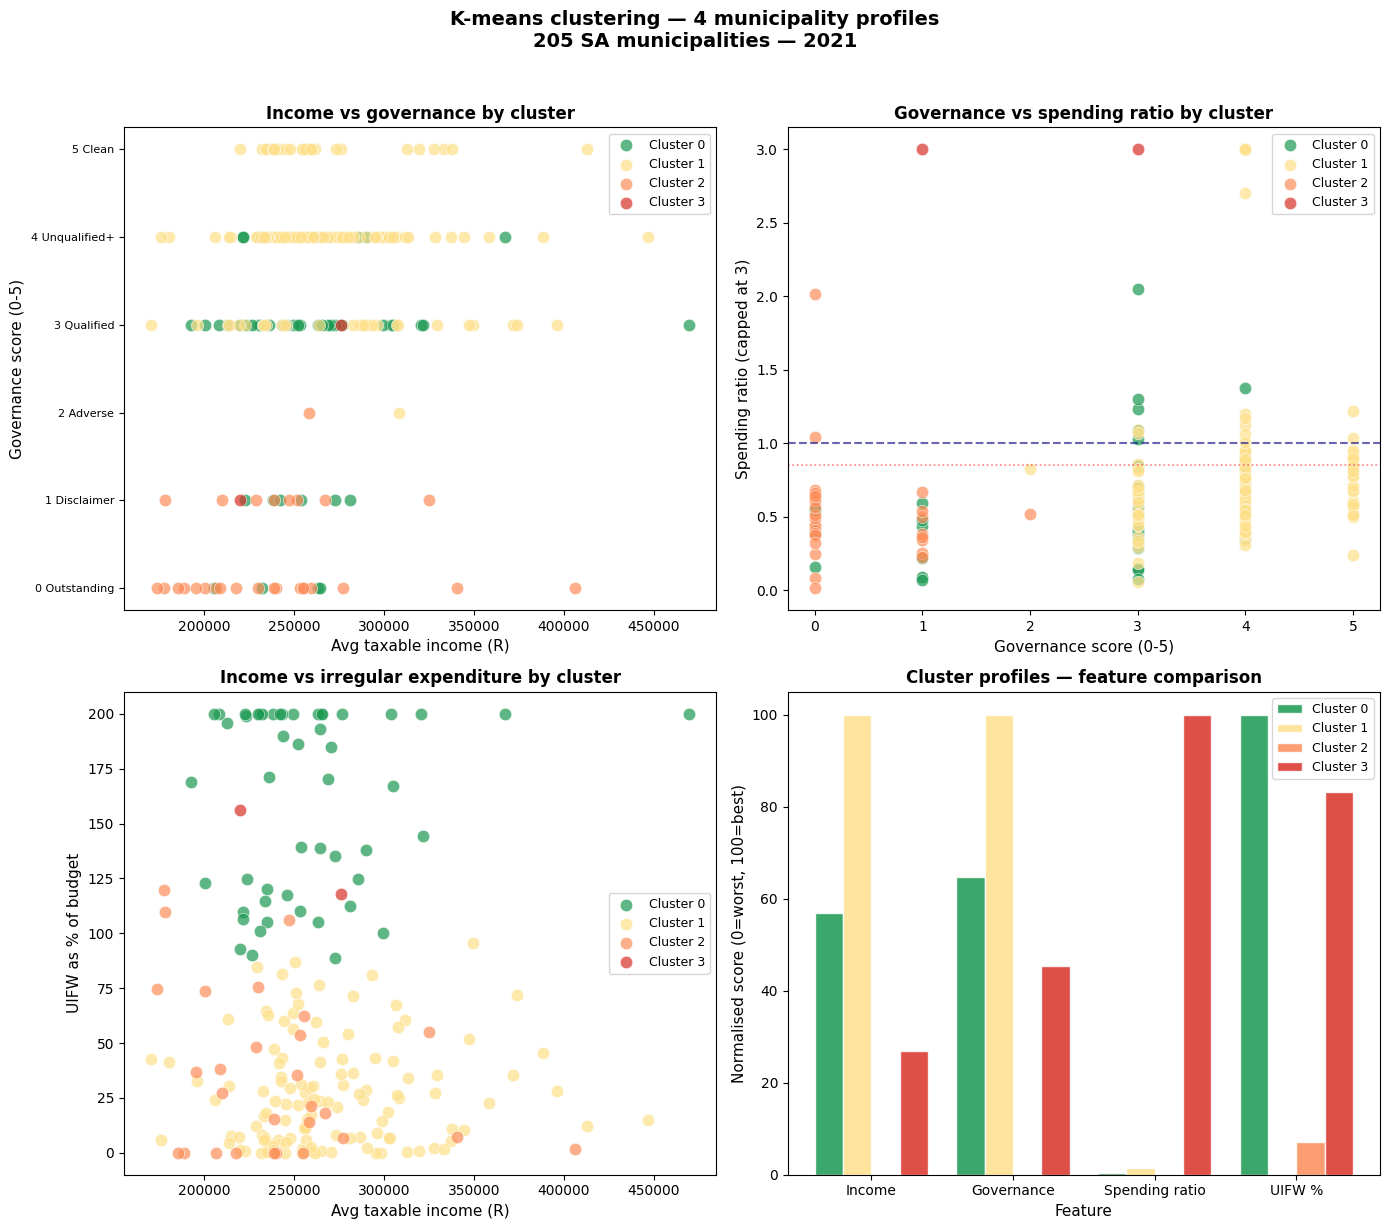


Sample municipalities per cluster:

Cluster 0 (n=50):
  muni_name      province  avg_taxable_income  governance_score  spending_ratio  uifw_pct_budget
   Gamagara Northern Cape            469674.0               3.0           1.300           200.00
Thaba Chweu    Mpumalanga            367382.0               4.0           0.910           200.00
   Mafikeng    North West            321533.0               3.0           0.655           144.44
Mogalakwena       Limpopo            320653.0               3.0           0.525           200.00
Govan Mbeki    Mpumalanga            304858.0               3.0           0.693           167.31

Cluster 1 (n=125):
           muni_name      province  avg_taxable_income  governance_score  spending_ratio  uifw_pct_budget
City of Johannesburg       Gauteng            446739.0               4.0           0.769            15.13
        Stellenbosch  Western Cape            412557.0               5.0           0.518            12.16
         Tsantsabane Nort

In [14]:
# ============================================
# K-MEANS — RUN WITH K=4
# ============================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# STEP 1 — Run K-means with k=4
# ============================================
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

# Assign cluster labels to municipalities
cluster_df['cluster'] = kmeans.labels_

print("Cluster sizes:")
print(cluster_df['cluster'].value_counts()
      .sort_index().to_string())

# ============================================
# STEP 2 — Profile each cluster
# What is the average of each variable per cluster
# ============================================
cluster_profiles = cluster_df.groupby('cluster')[
    features
].mean().round(2)

print(f"\nCluster profiles (mean values):")
print(cluster_profiles.to_string())

# ============================================
# STEP 3 — Province distribution per cluster
# Which provinces dominate each cluster
# ============================================
print(f"\nProvince distribution per cluster:")
province_cluster = pd.crosstab(
    cluster_df['cluster'],
    cluster_df['province'],
    normalize='index'
).round(3) * 100

print(province_cluster.to_string())

# ============================================
# STEP 4 — Name the clusters based on profiles
# We will assign names after seeing the profiles
# ============================================
# Placeholder names — we will update after analysis
cluster_names = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3'
}

cluster_df['cluster_name'] = cluster_df[
    'cluster'].map(cluster_names)

# ============================================
# STEP 5 — Visualise clusters
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

cluster_colors = {
    0: '#1a9850',
    1: '#fee08b',
    2: '#fc8d59',
    3: '#d73027'
}

# Plot 1 — Income vs governance coloured by cluster
for cluster_id, group in cluster_df.groupby('cluster'):
    axes[0, 0].scatter(
        group['avg_taxable_income'],
        group['governance_score'],
        c=cluster_colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.7, s=80,
        edgecolors='white', linewidth=0.5
    )
axes[0, 0].set_xlabel('Avg taxable income (R)', fontsize=11)
axes[0, 0].set_ylabel('Governance score (0-5)', fontsize=11)
axes[0, 0].set_title(
    'Income vs governance by cluster',
    fontweight='bold'
)
axes[0, 0].legend(fontsize=9)
axes[0, 0].set_yticks([0,1,2,3,4,5])
axes[0, 0].set_yticklabels([
    '0 Outstanding', '1 Disclaimer',
    '2 Adverse', '3 Qualified',
    '4 Unqualified+', '5 Clean'
], fontsize=8)

# Plot 2 — Governance vs spending ratio
for cluster_id, group in cluster_df.groupby('cluster'):
    axes[0, 1].scatter(
        group['governance_score'],
        group['spending_ratio'].clip(upper=3),
        c=cluster_colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.7, s=80,
        edgecolors='white', linewidth=0.5
    )
axes[0, 1].axhline(y=1.0, color='navy',
    linestyle='--', linewidth=1.5, alpha=0.6)
axes[0, 1].axhline(y=0.85, color='red',
    linestyle=':', linewidth=1.2, alpha=0.5)
axes[0, 1].set_xlabel('Governance score (0-5)', fontsize=11)
axes[0, 1].set_ylabel(
    'Spending ratio (capped at 3)', fontsize=11)
axes[0, 1].set_title(
    'Governance vs spending ratio by cluster',
    fontweight='bold'
)
axes[0, 1].legend(fontsize=9)

# Plot 3 — Income vs UIFW percentage
for cluster_id, group in cluster_df.groupby('cluster'):
    axes[1, 0].scatter(
        group['avg_taxable_income'],
        group['uifw_pct_budget'],
        c=cluster_colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.7, s=80,
        edgecolors='white', linewidth=0.5
    )
axes[1, 0].set_xlabel('Avg taxable income (R)', fontsize=11)
axes[1, 0].set_ylabel('UIFW as % of budget', fontsize=11)
axes[1, 0].set_title(
    'Income vs irregular expenditure by cluster',
    fontweight='bold'
)
axes[1, 0].legend(fontsize=9)

# Plot 4 — Cluster profile radar-style bar chart
cluster_profiles_norm = cluster_profiles.copy()
for col in features:
    col_min = cluster_profiles[col].min()
    col_max = cluster_profiles[col].max()
    if col_max > col_min:
        cluster_profiles_norm[col] = (
            (cluster_profiles[col] - col_min) /
            (col_max - col_min) * 100
        )

short_names = {
    'avg_taxable_income': 'Income',
    'governance_score':   'Governance',
    'spending_ratio':     'Spending ratio',
    'uifw_pct_budget':    'UIFW %'
}
cluster_profiles_norm = cluster_profiles_norm.rename(
    columns=short_names)

x = np.arange(len(short_names))
width = 0.2

for i, cluster_id in enumerate(
        cluster_profiles_norm.index):
    axes[1, 1].bar(
        x + i * width,
        cluster_profiles_norm.loc[cluster_id],
        width,
        label=f'Cluster {cluster_id}',
        color=cluster_colors[cluster_id],
        edgecolor='white',
        alpha=0.85
    )

axes[1, 1].set_xlabel('Feature', fontsize=11)
axes[1, 1].set_ylabel(
    'Normalised score (0=worst, 100=best)',
    fontsize=11
)
axes[1, 1].set_title(
    'Cluster profiles — feature comparison',
    fontweight='bold'
)
axes[1, 1].set_xticks(x + width * 1.5)
axes[1, 1].set_xticklabels(
    list(short_names.values()), fontsize=10)
axes[1, 1].legend(fontsize=9)

fig.suptitle(
    'K-means clustering — 4 municipality profiles\n'
    '205 SA municipalities — 2021',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '../outputs/kmeans_clusters.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# ============================================
# STEP 6 — Show sample municipalities per cluster
# ============================================
print(f"\nSample municipalities per cluster:")
for cluster_id in sorted(cluster_df['cluster'].unique()):
    sample = cluster_df[
        cluster_df['cluster'] == cluster_id
    ].nlargest(5, 'avg_taxable_income')[
        ['muni_name', 'province',
         'avg_taxable_income', 'governance_score',
         'spending_ratio', 'uifw_pct_budget']
    ]
    print(f"\nCluster {cluster_id} "
          f"(n={len(cluster_df[cluster_df['cluster']==cluster_id])}):")
    print(sample.to_string(index=False))

In [15]:
# ============================================
# NAME THE CLUSTERS
# ============================================

cluster_names = {
    0: 'At Risk — High irregular expenditure',
    1: 'Operational — Moderate governance',
    2: 'Failing — No financial accountability',
    3: 'Critical — Extreme budget breach'
}

cluster_df['cluster_name'] = cluster_df[
    'cluster'].map(cluster_names)

# Save clustered data
cluster_df.to_csv(
    '../data/cleaned/municipal_clusters_2021.csv',
    index=False
)

print("Cluster assignment summary:")
print(cluster_df.groupby(
    ['cluster', 'cluster_name']
).size().to_string())

print(f"\nSaved: municipal_clusters_2021.csv")

Cluster assignment summary:
cluster  cluster_name                         
0        At Risk — High irregular expenditure      50
1        Operational — Moderate governance        125
2        Failing — No financial accountability     28
3        Critical — Extreme budget breach           2

Saved: municipal_clusters_2021.csv


## K-Means Clustering Results — 4 Municipality Profiles
### 205 SA Municipalities — 2021

**Optimal k: 4 (silhouette score 0.407)**

---

### Cluster Profiles

**Cluster 1 — Functional (n=125, 61% of municipalities)**
- Avg income: R270,212
- Governance score: 3.97 (mostly clean audits)
- Spending ratio: 0.83 (spending 83% of budget)
- UIFW: 26.23% of budget
- Dominated by: Western Cape (17.6%), KZN (23.2%)
- Examples: Johannesburg, Stellenbosch, Tshwane
- Profile: Well governed municipalities across all
  income levels. Functional regardless of wealth.

**Cluster 0 — Dysfunctional High Irregularity (n=50)**
- Avg income: R257,033
- Governance score: 2.70 (qualified to adverse)
- Spending ratio: 0.60
- UIFW: 159.40% of budget
- Dominated by: North West (22%), Northern Cape (20%)
- Examples: Gamagara, Govan Mbeki, Mogalakwena
- Profile: Mixed income including wealthy mining
  municipalities. Extreme irregular expenditure
  defines this cluster not poverty.

**Cluster 2 — Collapsed (n=28)**
- Avg income: R239,662 (lowest)
- Governance score: 0.36 (outstanding/disclaimer)
- Spending ratio: 0.51
- UIFW: 35.72% of budget
- Dominated by: Northern Cape (28.6%), Free State (28.6%)
- Examples: Joe Morolong, Renosterberg, Madibeng
- Profile: Municipalities that have stopped functioning
  as accountable institutions. Cannot produce
  audited financial statements.

**Cluster 3 — Crisis Overspending (n=2)**
- Avg income: R247,906
- Governance score: 2.00
- Spending ratio: 22.98 (spending 23x budget)
- UIFW: 137.01% of budget
- Members: uMshwathi (KZN), Sundays River Valley (EC)
- Profile: Extreme financial catastrophe.
  Spending 17-29 times adjusted capital budget.
  Isolated by algorithm as statistical outliers.

---

### Key Finding

**Income does not determine governance quality.**

The primary differentiator between clusters is
institutional quality — audit outcomes, budget
management, irregular expenditure controls.
Not how wealthy the area is.

Gamagara (highest income municipality nationally
at R469,674) sits in the dysfunctional cluster
alongside municipalities earning R200,000.
Wealth without governance produces the same
outcomes as poverty without governance.

---

### Comparison to GHS Service Delivery (Phase 1)

Cluster 2 collapsed municipalities overlap
significantly with provinces that scored lowest
on the GHS service delivery analysis:
- Free State 28.6% of collapsed cluster
- Northern Cape 28.6% of collapsed cluster
- North West 14.3% of collapsed cluster

These are the same provinces with lowest DES scores,
worst refuse reliability, worst sanitation outcomes.
The financial collapse visible in Municipal Money
data directly corresponds to service delivery
failure visible in household survey data.

The two phases of analysis confirm each other.